In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from typing import List, Tuple

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [2]:
# y(Theta)を計算する関数
def y_SIS(deg_list, pk, lamb, gamma, Theta, c=0):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -Theta

    y = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        y += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    
    y /= k_ave
    y -= Theta
    return y

# y'(Theta) = dy/dTheta を計算する関数
def dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c=0.0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -1.0
    dy = 0.0
    for k, p in zip(deg_list, pk):
        B = gamma + lamb * k * Theta * (1.0 + c * k * Theta)  # 正しい分母
        if B == 0:
            return np.nan
        fprime = (lamb * gamma * k * (1.0 + 2.0 * c * k * Theta)) / (B ** 2)
        dy += k * p * fprime
    dy /= k_ave
    dy -= 1.0
    return dy


# ニュートン法を実装した関数
def newton_method(deg_list, pk, lamb, gamma, Theta_initial=0.9, tolerance=1e-16, max_iter=100, c=0):
    """
    ニュートン法を用いて y_SIS(Theta) = 0 となるThetaを探す
    """
    Theta = Theta_initial
    for i in range(max_iter):
        y_val = y_SIS(deg_list, pk, lamb, gamma, Theta, c)
        
        # yが十分に0に近ければ終了
        if abs(y_val) < tolerance:
            return Theta

        dy_val = dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c)

        # 導関数が0に近く、更新が発散しそうな場合は終了
        if abs(dy_val) < 1e-10:
            # print(f"Warning: Derivative is too small at lambda={lamb}, Theta={Theta}. Stopping.")
            return Theta

        # ニュートン法の更新式
        Theta_new = Theta - y_val / dy_val
        
        # 更新量が十分に小さくなれば終了
        if abs(Theta_new - Theta) < tolerance:
            return Theta_new
            
        Theta = Theta_new
        
    # print(f"Warning: Newton's method did not converge for lambda={lamb} within {max_iter} iterations.")
    return Theta

def theta_to_I(deg_list, pk, lamb, gamma, Theta, c=0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return 0
    I = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        I += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    I /= k_ave
    return I

In [4]:
z_list = [4, 6, 10, 12]
c_list = [0.0, 0.7, 1.8]
lamb_values_for_theory = np.linspace(0.0, 0.3, 10000)

theta_all = np.zeros((len(c_list), len(z_list), len(lamb_values_for_theory)))
gamma = 1.0

for cidx, c in enumerate(c_list):

    for zidx, z in enumerate(z_list):
        theta_results = []
        k_ave = z
        # 各lambdaについてニュートン法でThetaを解く
        for lamb in lamb_values_for_theory:
            # 次数のリスト
            deg_list = [k_ave]
            pk = np.array([1.0])

            # 初期値は重要。ここでは前のステップの結果を流用すると収束しやすいが、簡単のため固定値から始める
            # 問題によってはTheta=0も根になる（自明な解）ため、0以外の初期値を選ぶ
            solution = newton_method(deg_list, pk, lamb, gamma, c=c)
            
            # 物理的に意味のある解は Theta >= 0
            if solution < 0:
                solution = 0
                
            theta_results.append(solution)
            # print(f"{lamb:.4f}, {solution:.8f}")

        theta_all[cidx, zidx, :] = theta_results

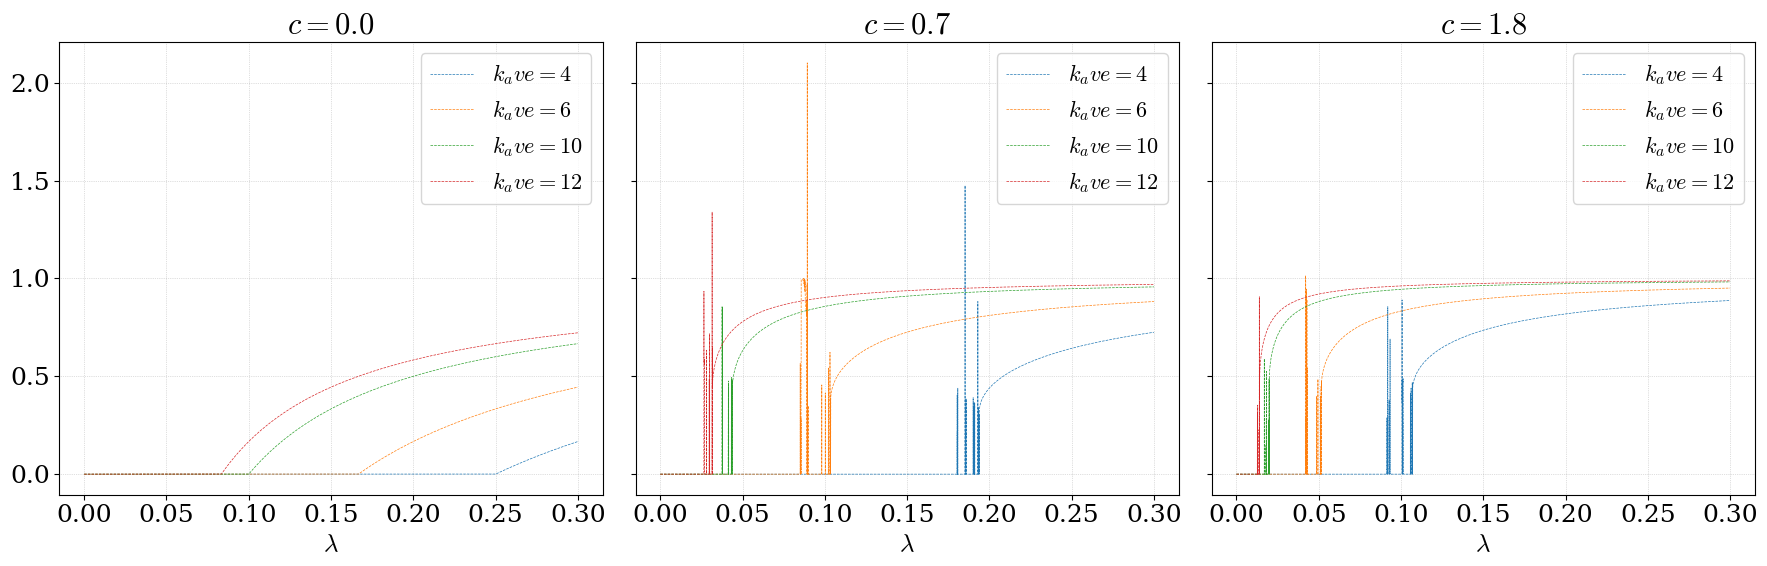

In [5]:
fig, axes = plt.subplots(1, len(c_list), figsize=(6 * len(c_list), 6), sharey=True)

for c_idx, c in enumerate(c_list):
    for zidx, z in enumerate(z_list):
        k_ave = z
        deg_list = [k_ave]
        pk = np.array([1.0])

        axes[c_idx].plot(lamb_values_for_theory, theta_all[c_idx, zidx, :], color=colors[zidx], label=f"$k_ave={z}$", linestyle="--", linewidth=0.5)
        axes[c_idx].legend()
        axes[c_idx].grid(True, linestyle=":", alpha=0.5)
        axes[c_idx].set_title(rf"$c={c}$")
        axes[c_idx].set_xlabel(r"$\lambda$")

fig.tight_layout()

plt.show()